# LLM Token Cost Anomaly Detection

**Objective:** Detect expensive or looping LLM requests from tokens, latency, tool calls, retries, context ratio, and estimated cost.

This notebook trains without labels. A small injected scenario flag is retained only to test the alerting workflow after scoring.


## 1. Setup and reproducibility


In [1]:
import platform
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
sns.set_theme(style="whitegrid", palette="deep")

print(f"Python: {platform.python_version()}")
print(f"pandas: {pd.__version__} | NumPy: {np.__version__} | scikit-learn: {sklearn.__version__}")
print(f"Random seed: {RANDOM_STATE}")


Python: 3.12.13
pandas: 2.2.3 | NumPy: 2.3.5 | scikit-learn: 1.8.0
Random seed: 42


## 2. Generate normal behavior and rare stress scenarios


In [2]:
FEATURES = ["input_tokens", "output_tokens", "latency_seconds", "tool_calls", "retry_count", "estimated_cost_usd"]
MEANS = np.asarray([2600, 620, 8, 2, 0.2, 0.035], dtype=float)
STDS = np.asarray([700, 210, 2.5, 1, 0.5, 0.012], dtype=float)
SHIFTS = np.asarray([8, 7, 6, 8, 12, 10], dtype=float)

normal = rng.normal(MEANS, STDS, size=(960, len(FEATURES)))
stress = rng.normal(MEANS + SHIFTS * STDS, STDS * 0.55, size=(40, len(FEATURES)))
values = np.vstack([normal, stress])
values = np.maximum(values, 0)
data = pd.DataFrame(values, columns=FEATURES)
data["scenario_anomaly"] = np.r_[np.zeros(len(normal), dtype=int), np.ones(len(stress), dtype=int)]
data = data.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
print(f"Dataset: {len(data):,} windows | stress scenarios retained for retrospective checks: {data['scenario_anomaly'].sum()}")
display(data.head().round(3))
display(data[FEATURES].describe().T.round(3))


Dataset: 1,000 windows | stress scenarios retained for retrospective checks: 40


,input_tokens,output_tokens,latency_seconds,tool_calls,retry_count,estimated_cost_usd,scenario_anomaly
0,2570.122,706.707,6.185,2.370,0.534,0.027,0
1,1604.791,473.907,5.490,2.728,0.285,0.018,0
2,2833.200,166.768,7.907,0.980,0.251,0.022,0
3,3516.668,901.453,9.292,1.545,0.080,0.025,0
4,2291.644,897.726,9.655,2.016,0.000,0.030,0


,count,mean,std,min,25%,50%,75%,max
input_tokens,1000.0,2820.157,1305.664,448.879,2169.828,2634.533,3108.404,9243.561
output_tokens,1000.0,669.210,364.725,0.000,470.131,627.348,761.645,2382.025
latency_seconds,1000.0,8.500,3.877,0.969,6.234,8.078,9.846,26.490
tool_calls,1000.0,2.366,1.827,0.000,1.392,2.037,2.848,11.764
retry_count,1000.0,0.550,1.208,0.000,0.000,0.227,0.580,6.639
estimated_cost_usd,1000.0,0.040,0.027,0.000,0.027,0.036,0.044,0.166


## 3. Robust scaling and label-free detector fitting


In [3]:
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
X = scaler.fit_transform(data[FEATURES])
contamination = 0.04

isolation = IsolationForest(n_estimators=240, contamination=contamination, random_state=RANDOM_STATE, n_jobs=1)
data["isolation_flag"] = (isolation.fit_predict(X) == -1).astype(int)
data["isolation_score"] = -isolation.score_samples(X)

lof = LocalOutlierFactor(n_neighbors=35, contamination=contamination)
data["lof_flag"] = (lof.fit_predict(X) == -1).astype(int)
data["lof_score"] = -lof.negative_outlier_factor_
print(f"Isolation Forest alerts: {data['isolation_flag'].sum()} | LOF alerts: {data['lof_flag'].sum()}")


Isolation Forest alerts: 40 | LOF alerts: 40


## 4. Retrospective detector diagnostics


In [4]:
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score

rows = []
for name in ["isolation", "lof"]:
    rows.append({
        "detector": name,
        "precision": precision_score(data["scenario_anomaly"], data[f"{name}_flag"], zero_division=0),
        "recall": recall_score(data["scenario_anomaly"], data[f"{name}_flag"], zero_division=0),
        "f1": f1_score(data["scenario_anomaly"], data[f"{name}_flag"], zero_division=0),
        "roc_auc_from_score": roc_auc_score(data["scenario_anomaly"], data[f"{name}_score"]),
    })
diagnostics = pd.DataFrame(rows).sort_values("f1", ascending=False)
display(diagnostics.round(4))
print("Scenario labels were not used during scaling, detector fitting, or threshold selection.")


Scenario labels were not used during scaling, detector fitting, or threshold selection.


,detector,precision,recall,f1,roc_auc_from_score
0,isolation,1.0,1.0,1.0,1.0000
1,lof,0.0,0.0,0.0,0.1941


## 5. Alert queue and feature-level context


In [5]:
median = data[FEATURES].median()
mad = (data[FEATURES] - median).abs().median().replace(0, 1e-9)
robust_deviation = ((data[FEATURES] - median) / mad).abs()
data["largest_deviation_feature"] = robust_deviation.idxmax(axis=1)
data["largest_robust_deviation"] = robust_deviation.max(axis=1)
alerts = data.sort_values("isolation_score", ascending=False).head(12)
display(alerts[FEATURES + ["isolation_score", "largest_deviation_feature", "largest_robust_deviation", "scenario_anomaly"]].round(3))


,input_tokens,output_tokens,latency_seconds,tool_calls,retry_count,estimated_cost_usd,isolation_score,largest_deviation_feature,largest_robust_deviation,scenario_anomaly
388,7491.733,1918.648,23.912,8.472,6.537,0.143,0.732,retry_count,27.840,1
561,7828.019,1920.231,23.308,10.887,6.256,0.146,0.716,retry_count,26.600,1
251,8524.688,1987.368,24.442,11.764,5.575,0.160,0.716,retry_count,23.596,1
569,9074.974,2113.719,21.934,10.226,6.071,0.146,0.711,retry_count,25.784,1
792,9243.561,1950.896,21.268,9.474,6.172,0.161,0.709,retry_count,26.229,1
767,8341.736,2318.100,24.234,9.871,6.428,0.166,0.708,retry_count,27.359,1
505,9128.329,2155.420,22.181,11.060,6.104,0.156,0.707,retry_count,25.932,1
605,8178.464,2294.329,23.737,9.498,6.000,0.164,0.706,retry_count,25.471,1
872,8500.154,2087.534,24.563,10.723,6.530,0.163,0.706,retry_count,27.809,1
117,8377.386,2323.057,23.244,11.346,6.249,0.155,0.704,retry_count,26.569,1


## 6. Two-dimensional anomaly map


Detector score correlation: 0.3791


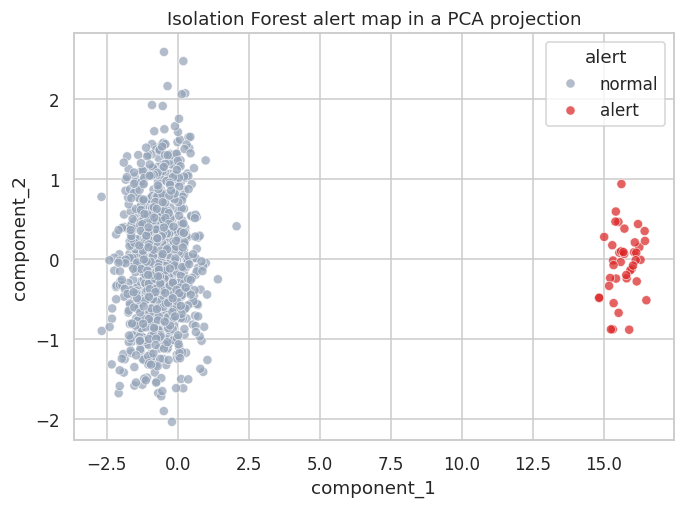

In [6]:
from sklearn.decomposition import PCA

projection = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X)
plot_data = pd.DataFrame({"component_1": projection[:, 0], "component_2": projection[:, 1], "alert": data["isolation_flag"].map({0: "normal", 1: "alert"})})
sns.scatterplot(data=plot_data, x="component_1", y="component_2", hue="alert", palette={"normal": "#94a3b8", "alert": "#dc2626"}, alpha=0.72)
plt.title("Isolation Forest alert map in a PCA projection")
plt.tight_layout()
plt.show()
print(f"Detector score correlation: {data[['isolation_score', 'lof_score']].corr().iloc[0, 1]:.4f}")


## 7. Findings and limitations

- Anomaly scores prioritize investigation; they do not prove malicious activity, failure, or waste.
- The injected stress cases demonstrate evaluation mechanics only.
- Production thresholds should be calibrated to alert capacity, missed-event cost, seasonality, and feedback from investigators.
